# **traininingAggression project:** SpikeSorting pipeline (3 probe pipeline)

In [17]:
# conda install pytorch torchvision torchaudio pytorch-cuda=11.8 -c pytorch -c nvidia

from pathlib import Path
import numpy as np
import subprocess, sys, time
import shutil
import torch
import kilosort
import spikeinterface.full as si
from spikeinterface.preprocessing import bandpass_filter, common_reference
from spikeinterface.sortingcomponents.motion import interpolate_motion
import matplotlib.pylab as plt
import random
from itertools import groupby

seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
torch.cuda.manual_seed_all(seed)

In [18]:
dt_folder = Path(r"J:\project_trainingAggression\Data")

ni_data = sorted(dt_folder.rglob("*nidq.bin"))
run_folders = [rf.parent for rf in ni_data]
s = "catgt_"
catGT_runs = [cgt.name.split(s)[1] for cgt in sorted(dt_folder.rglob("catgt*"))]

unprocessed_neuralData_folders = [rf for rf in run_folders if rf.name[len(s):] not in catGT_runs]

if len(unprocessed_neuralData_folders) == 0:
    print("No files to process found.")
else: 
    print("Runs to process with catGT:")
    for rf in unprocessed_neuralData_folders:
        print("  ", rf)

No files to process found.


## **Pre-processing & Sorting**

https://billkarsh.github.io/SpikeGLX/help/syncEdges/Sync_edges/

### catGT: Single probe demultiplexing corrections and TTL event extraction

**Documentation:** file:///C:/Users/Data%20Analysis/Desktop/CatGT-win/ReadMe.html

If Exit code 42, see CatGT log in __J:\project_trainingAggression\Code\Neurpixels_aggressionTraining\CatGT.txt__

In [10]:
catGT = (r"C:\Users\Data Analysis\Desktop\CatGT-win\CatGT.exe")

for folderRun in unprocessed_neuralData_folders:

    start = time.time()

    dataFolder = folderRun.parent
    spikeGLX_run = folderRun.name 
    if ("_g0" in spikeGLX_run):
        spikeGLX_run = spikeGLX_run[0:-3]# Removes "_g0" from filename

    print(f"Multiplexer temporal shift correction in session: {spikeGLX_run}")

    cmd = [
            str(catGT),
            f"-dir={dataFolder}",  
            f"-run={spikeGLX_run}",
            "-g=0",
            "-t=0",            
            "-ap",              # Process Action Potential (.ap.bin) files
            "-prb=0:2",         # Probe 1 to 3
            "-ni",              # Process the auxiliary data (.niqd.bin) containing both Analog and Digital channels
            "-prb_fld",         # 1 probe per folder
            #"-maxsecs=1205.00", # 20 min + 5 seconds


            # ========= -xd = js,ip,word,bit,pulsewidth(ms),tol(ms) =========

            "-xid=0,0,-1,2,50,5",               # Sweetened milk events: falling edges (P.02)
            #"-xd=0,0,-1,2,15000, 1000",        # Sweetened milk events: rising edges (P.02)

            "-xd=0,0,-1,3,0",                   # LED red light ON: rising edges (P.03)
            "-xid=0,0,-1,3,360000,5000",        # LED white light ON: falling edge (P.03)  

            "-xd=0,0,-1,4, 1000000,500000",     # Gate OPEN: rising edge (P.04)

            "-xd=0,0,-1,5,3500,500",            # uArm ON: rising edges (P.05)
            "-xid=0,0,-1,5,11000,3000",         # uArm OFF: falling edges (P.05) (Not all of them will be picked up but it is good to know the average trial duration)

            f"-dest={dataFolder}",
            "-pass1_force_ni_ob_bin",
            "-out_prb_fld",
          ]
    
    p = subprocess.Popen(cmd, stdout=subprocess.PIPE, stderr=subprocess.STDOUT, text=True)
    for line in p.stdout:
        sys.stdout.write(line)
    rc = p.wait()

    shutil.rmtree(folderRun) # Deleting original run folder

    end = time.time()

    print(f"Exit code: {rc}. Running time (1 SpikeGLX run): {(end - start)/60: .2f} min.\n")


Multiplexer temporal shift correction in session: 20260415_m1013587_obs2
Exit code: 0. Running time (1 SpikeGLX run):  213.10 min.



### **Band-pass filtering (300 - 6000 Hz), Common Median Reference (CRM), Motion correction (DREDge), whitening and spike sorting (Kilosort4)**

**SpikeInterface documentation:** https://spikeinterface.readthedocs.io/en/stable/overview.html

**High level pipeline for motion correction using DREDge:** https://spikeinterface.readthedocs.io/en/latest/how_to/handle_drift.html

**Low level pipeline for motion correction using DREDge:** https://spikeinterface.readthedocs.io/en/latest/modules/sortingcomponents.html#motion-interpolation


In [16]:
def session_key(p):
    p = str(p)  # works for string paths or Path objects
    return next(part for part in p.split("\\") if part.startswith("catgt_"))

In [19]:
def filter_unprocessed(files):
    out = []
    for f in files:
        if not any(p.is_dir() for p in f.parent.rglob("kilosort4*")):
            out.append(f)
    return out

tcat_bin_files  = filter_unprocessed(sorted(dt_folder.rglob("*_tcat.imec*.ap.bin")))
tcat_meta_files = filter_unprocessed(sorted(dt_folder.rglob("*_tcat.imec*.ap.meta")))

# groupby needs equal keys adjacent, so sort first
paths_sorted = sorted(tcat_bin_files, key=session_key)

session_groups = [list(g) for _, g in groupby(paths_sorted, key=session_key)]
session_groups

[]

__Motion correction plots meaning:__

top left: time vs estimated peak

top right: time vs peak depth after motion correction

bottom left: the average motion vector across depths and all motion across spatial depths (for non-rigid estimation)

bottom right: if motion correction is non rigid, the motion vector across depths is plotted as a map, with the color code representing the motion in micrometers.

Compute DREDge motion correction on session: 20260415_m1013587_obs2_g0


noise_level (no parallelization):   0%|          | 0/20 [00:00<?, ?it/s]

detect and localize (workers: 16 processes):   0%|          | 0/3084 [00:00<?, ?it/s]

Cross correlation:   0%|          | 0/9 [00:00<?, ?it/s]

Solve:   0%|          | 0/8 [00:00<?, ?it/s]

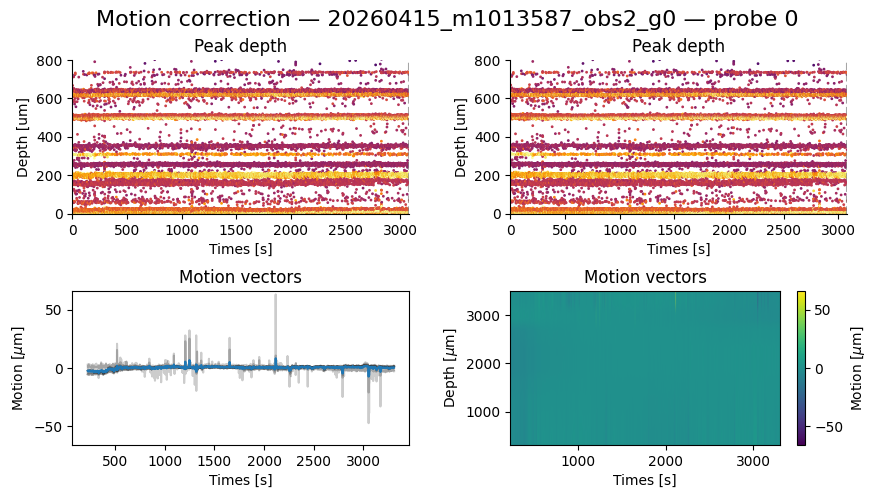

write_binary_recording (workers: 16 processes):   0%|          | 0/3084 [00:00<?, ?it/s]

kilosort.run_kilosort:  
kilosort.run_kilosort: Computing drift correction.
kilosort.run_kilosort: ----------------------------------------
kilosort.datashift: nblocks = 0, skipping drift correction
kilosort.run_kilosort: drift computed in 0.01s; total 0.02s
kilosort.run_kilosort:  
kilosort.run_kilosort: Resource usage after drift correction
kilosort.run_kilosort: ********************************************************
kilosort.run_kilosort: CPU usage:    78.60 %
kilosort.run_kilosort: Mem used:     55.40 %     |      70.85 GB
kilosort.run_kilosort: Mem avail:    57.15 / 128.00 GB
kilosort.run_kilosort: ------------------------------------------------------
kilosort.run_kilosort: GPU usage:    `conda install pynvml` for GPU usage
kilosort.run_kilosort: GPU memory:   54.77 %     |      6.57   /    12.00 GB
kilosort.run_kilosort: Allocated:     0.07 %     |      0.01   /    12.00 GB
kilosort.run_kilosort: Max alloc:     7.89 %     |      0.95   /    12.00 GB
kilosort.run_kilosort: ****

Skipping common average reference.
Skipping kilosort preprocessing.
Skipping drift correction.


kilosort.spikedetect: Number of universal templates: 1488
kilosort.spikedetect: Detecting spikes...
100%|██████████| 1542/1542 [13:43:10<00:00, 32.03s/it]  
kilosort.run_kilosort: 7137676 spikes extracted in 51287.06s; total 51287.11s
kilosort.run_kilosort:  
kilosort.run_kilosort: Resource usage after spike detect (univ)
kilosort.run_kilosort: ********************************************************
kilosort.run_kilosort: CPU usage:    100.00 %
kilosort.run_kilosort: Mem used:     15.90 %     |      20.29 GB
kilosort.run_kilosort: Mem avail:    107.71 / 128.00 GB
kilosort.run_kilosort: ------------------------------------------------------
kilosort.run_kilosort: GPU usage:    `conda install pynvml` for GPU usage
kilosort.run_kilosort: GPU memory:   54.77 %     |      6.57   /    12.00 GB
kilosort.run_kilosort: Allocated:     0.08 %     |      0.01   /    12.00 GB
kilosort.run_kilosort: Max alloc:    26.78 %     |      3.21   /    12.00 GB
kilosort.run_kilosort: ***********************

kilosort4 run time 54123.84s


noise_level (no parallelization):   0%|          | 0/20 [00:00<?, ?it/s]

detect and localize (workers: 16 processes):   0%|          | 0/3084 [00:00<?, ?it/s]

Cross correlation:   0%|          | 0/9 [00:00<?, ?it/s]

Solve:   0%|          | 0/8 [00:00<?, ?it/s]

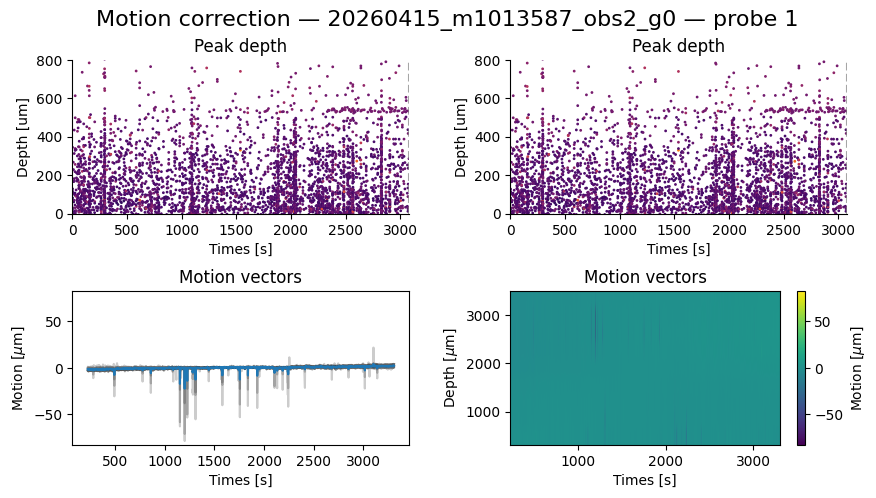

write_binary_recording (workers: 16 processes):   0%|          | 0/3084 [00:00<?, ?it/s]

kilosort.run_kilosort:  
kilosort.run_kilosort: Computing drift correction.
kilosort.run_kilosort: ----------------------------------------
kilosort.datashift: nblocks = 0, skipping drift correction
kilosort.run_kilosort: drift computed in 0.01s; total 0.01s
kilosort.run_kilosort:  
kilosort.run_kilosort: Resource usage after drift correction
kilosort.run_kilosort: ********************************************************
kilosort.run_kilosort: CPU usage:    13.30 %
kilosort.run_kilosort: Mem used:     15.90 %     |      20.33 GB
kilosort.run_kilosort: Mem avail:    107.67 / 128.00 GB
kilosort.run_kilosort: ------------------------------------------------------
kilosort.run_kilosort: GPU usage:    `conda install pynvml` for GPU usage
kilosort.run_kilosort: GPU memory:   54.79 %     |      6.57   /    12.00 GB
kilosort.run_kilosort: Allocated:     0.07 %     |      0.01   /    12.00 GB
kilosort.run_kilosort: Max alloc:     7.89 %     |      0.95   /    12.00 GB
kilosort.run_kilosort: ***

Skipping common average reference.
Skipping kilosort preprocessing.
Skipping drift correction.


kilosort.spikedetect: Number of universal templates: 1496
kilosort.spikedetect: Detecting spikes...
100%|██████████| 1542/1542 [31:20<00:00,  1.22s/it]
kilosort.run_kilosort: 5458664 spikes extracted in 1902.39s; total 1902.45s
kilosort.run_kilosort:  
kilosort.run_kilosort: Resource usage after spike detect (univ)
kilosort.run_kilosort: ********************************************************
kilosort.run_kilosort: CPU usage:     0.00 %
kilosort.run_kilosort: Mem used:     17.30 %     |      22.12 GB
kilosort.run_kilosort: Mem avail:    105.88 / 128.00 GB
kilosort.run_kilosort: ------------------------------------------------------
kilosort.run_kilosort: GPU usage:    `conda install pynvml` for GPU usage
kilosort.run_kilosort: GPU memory:   54.79 %     |      6.57   /    12.00 GB
kilosort.run_kilosort: Allocated:     0.08 %     |      0.01   /    12.00 GB
kilosort.run_kilosort: Max alloc:    26.98 %     |      3.24   /    12.00 GB
kilosort.run_kilosort: *******************************

kilosort4 run time 3737.78s


noise_level (no parallelization):   0%|          | 0/20 [00:00<?, ?it/s]

detect and localize (workers: 16 processes):   0%|          | 0/3084 [00:00<?, ?it/s]

Cross correlation:   0%|          | 0/9 [00:00<?, ?it/s]

Solve:   0%|          | 0/8 [00:00<?, ?it/s]

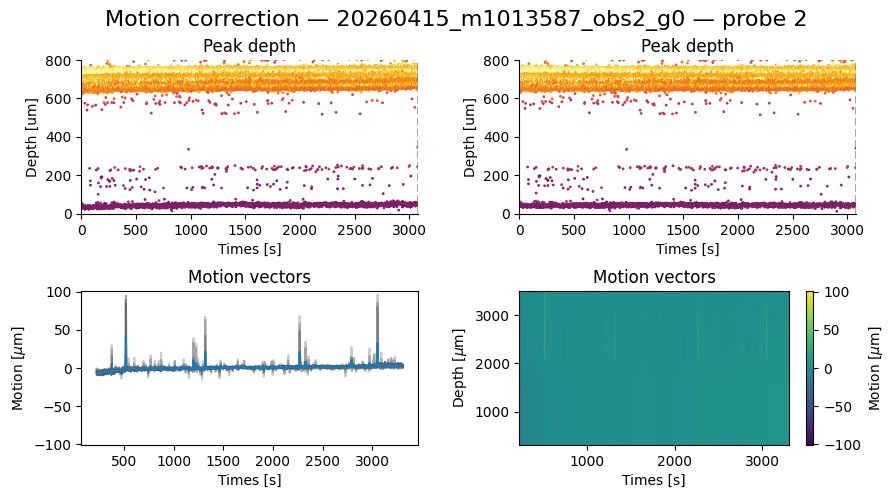

write_binary_recording (workers: 16 processes):   0%|          | 0/3084 [00:00<?, ?it/s]

kilosort.run_kilosort:  
kilosort.run_kilosort: Computing drift correction.
kilosort.run_kilosort: ----------------------------------------
kilosort.datashift: nblocks = 0, skipping drift correction
kilosort.run_kilosort: drift computed in 0.01s; total 0.01s
kilosort.run_kilosort:  
kilosort.run_kilosort: Resource usage after drift correction
kilosort.run_kilosort: ********************************************************
kilosort.run_kilosort: CPU usage:     0.00 %
kilosort.run_kilosort: Mem used:     15.90 %     |      20.36 GB
kilosort.run_kilosort: Mem avail:    107.64 / 128.00 GB
kilosort.run_kilosort: ------------------------------------------------------
kilosort.run_kilosort: GPU usage:    `conda install pynvml` for GPU usage
kilosort.run_kilosort: GPU memory:   54.79 %     |      6.57   /    12.00 GB
kilosort.run_kilosort: Allocated:     0.07 %     |      0.01   /    12.00 GB
kilosort.run_kilosort: Max alloc:     7.89 %     |      0.95   /    12.00 GB
kilosort.run_kilosort: ***

Skipping common average reference.
Skipping kilosort preprocessing.
Skipping drift correction.


kilosort.spikedetect: Number of universal templates: 1480
kilosort.spikedetect: Detecting spikes...
100%|██████████| 1542/1542 [33:32<00:00,  1.31s/it]
kilosort.run_kilosort: 8052905 spikes extracted in 2035.54s; total 2035.58s
kilosort.run_kilosort:  
kilosort.run_kilosort: Resource usage after spike detect (univ)
kilosort.run_kilosort: ********************************************************
kilosort.run_kilosort: CPU usage:     0.00 %
kilosort.run_kilosort: Mem used:     19.20 %     |      24.53 GB
kilosort.run_kilosort: Mem avail:    103.47 / 128.00 GB
kilosort.run_kilosort: ------------------------------------------------------
kilosort.run_kilosort: GPU usage:    `conda install pynvml` for GPU usage
kilosort.run_kilosort: GPU memory:   54.79 %     |      6.57   /    12.00 GB
kilosort.run_kilosort: Allocated:     0.08 %     |      0.01   /    12.00 GB
kilosort.run_kilosort: Max alloc:    26.72 %     |      3.21   /    12.00 GB
kilosort.run_kilosort: *******************************

kilosort4 run time 4887.96s


In [13]:
preset = "dredge"
params_kilosort4 = {'do_CAR': False,
                    'skip_kilosort_preprocessing': True,
                    'do_correction': False,
                    'torch_device':'cuda',
                    'delete_recording_dat': False,
                    'n_jobs': 16}


for session in session_groups:

    session_name = str(session[0].name).split("_tcat")[0]

    print("Compute DREDge motion correction on session:", session_name)

    for it, probe in enumerate(session):

        ''' ==================================== Pre-processing: BP filter and CMR ==================================== '''

        raw_rec = si.read_spikeglx(probe.parent, 
                                   stream_name=f'imec{it}.ap', 
                                   load_sync_channel=False)

        pre_processed_rec = common_reference(bandpass_filter(recording = raw_rec,
                                                            freq_min = 300,
                                                            freq_max = 6000), 
                                            operator="median", 
                                            reference="global")

        ''' ==================================== Motion correction: DREDge ==================================== '''

        motion, motion_info = si.compute_motion(pre_processed_rec, 
                                                preset=preset, 
                                                folder=f"{probe.parent}/DREDge_probe{it}" , 
                                                output_motion_info=True,
                                                n_jobs = 16)
        
        fig = plt.figure(figsize=(10, 5))

        si.plot_motion_info(
            motion_info, 
            pre_processed_rec,
            figure = fig,
            depth_lim=(0, 800),
            color_amplitude=True,
            amplitude_cmap="inferno",
            scatter_decimate=10,
        )

        fig.suptitle(f"Motion correction — {session_name} — probe {it}",
                     fontsize=16)
        plt.show()

        interpolated_rec = interpolate_motion(recording=pre_processed_rec.astype('float32'), 
                                              motion=motion)
        
        ''' ==================================== Spikesorting: Whitening ==================================== '''

        ''' Mimics Kilosort4 whitening
        motion_corrected_rec = si.whiten(interpolated_rec,
                                         dtype="float32",
                                         mode="local",
                                         apply_mean=False,
                                         radius_um=100.0,
                                         num_chunks_per_segment=25,
                                         chunk_size=60000,
                                         seed=42)
        '''

        motion_corrected_rec = si.whiten(interpolated_rec)  

        ''' ==================================== Spikesorting: Kilosort4 ==================================== '''
        
        params_kilosort4['fs'] = interpolated_rec.get_sampling_frequency()

        sorting = si.run_sorter('kilosort4', 
                                 motion_corrected_rec, 
                                 folder=f"{probe.parent}/Kilosort4_probe{it}", 
                                 verbose=True, 
                                 **params_kilosort4)

        del motion, motion_info, interpolated_rec, sorting

### TPrime: Align events across probes and NI analog + TTL data

In [14]:
# First a conversion from samples to seconds is required in the spike sorted data

spk_time_files = dt_folder.rglob("*spike_times.npy")
aready_processed = [ard_prc.parent for ard_prc in (dt_folder.rglob("*spike_seconds.npy"))]

spk_time_files_2proc = [spk_file for spk_file in spk_time_files if spk_file.parent not in aready_processed]

for spk_file in spk_time_files_2proc:

    ops = np.load(spk_file.parent / "ops.npy", allow_pickle = True)
    fs = float(ops.item()['fs'])

    print(spk_file)

    fl = np.load(spk_file)

    samples_to_seconds = fl/fs
    newfile_path = spk_file.parent / "spike_seconds.npy"

    np.save(newfile_path, samples_to_seconds)


J:\project_trainingAggression\Data\ParadigmControls\20260415_mouse1013587\Day03\neuralData\catgt_20260415_m1013587_obs2_g0\20260415_m1013587_obs2_g0_imec0\Kilosort4_probe0\sorter_output\spike_times.npy
J:\project_trainingAggression\Data\ParadigmControls\20260415_mouse1013587\Day03\neuralData\catgt_20260415_m1013587_obs2_g0\20260415_m1013587_obs2_g0_imec1\Kilosort4_probe1\sorter_output\spike_times.npy
J:\project_trainingAggression\Data\ParadigmControls\20260415_mouse1013587\Day03\neuralData\catgt_20260415_m1013587_obs2_g0\20260415_m1013587_obs2_g0_imec2\Kilosort4_probe2\sorter_output\spike_times.npy
J:\project_trainingAggression\Data\ParadigmControls\20260415_mouse1034811\Day03\neuralData\catgt_20260415_m1034811_obs2_g0\20260415_m1034811_obs2_g0_imec0\Kilosort4_probe0\sorter_output\spike_times.npy
J:\project_trainingAggression\Data\ParadigmControls\20260415_mouse1034811\Day03\neuralData\catgt_20260415_m1034811_obs2_g0\20260415_m1034811_obs2_g0_imec1\Kilosort4_probe1\sorter_output\spike_

In [15]:
tprime = (r"C:\Users\Data Analysis\Desktop\TPrime-win\TPrime.exe")

already_converted = [stream.parent.parent.parent.parent for stream in dt_folder.rglob("*spike_seconds_imec*_adj.npy")]

all_master_streams_ni = dt_folder.rglob("*nidq.xd_*_0_500.txt")
master_streams_ni_2proc = [stream for stream in all_master_streams_ni if stream.parent not in already_converted]

for id, ni_stream in enumerate(master_streams_ni_2proc):

    start = time.time()
    
    print(f"Aligning session: {ni_stream.parent}")

    prb_streams = [prb for prb in (ni_stream.parent.rglob("*tcat.imec*.ap.xd*"))]

    spk_sec_prb0 = next(prb_streams[0].parent.rglob("*spike_seconds.npy"))
    conv_spk_sec_prb0 = spk_sec_prb0.parent / "spike_seconds_imec0_adj.npy"

    spk_sec_prb1 = next(prb_streams[1].parent.rglob("*spike_seconds.npy"))
    conv_spk_sec_prb1 = spk_sec_prb1.parent / "spike_seconds_imec1_adj.npy"

    spk_sec_prb2 = next(prb_streams[2].parent.rglob("*spike_seconds.npy"))
    conv_spk_sec_prb2 = spk_sec_prb2.parent / "spike_seconds_imec2_adj.npy"
    
    cmd = [
    tprime,
    "-syncperiod=1.0",
    f"-tostream={ni_stream}",
    f"-fromstream=1,{prb_streams[0]}",
    f"-fromstream=2,{prb_streams[1]}",
    f"-fromstream=3,{prb_streams[2]}",
    f"-events=1,{spk_sec_prb0},{conv_spk_sec_prb0}",
    f"-events=2,{spk_sec_prb1},{conv_spk_sec_prb1}",
    f"-events=3,{spk_sec_prb2},{conv_spk_sec_prb2}",
    ]

    start = time.time()

    p = subprocess.Popen(cmd, stdout=subprocess.PIPE, stderr=subprocess.STDOUT, text=True)
    for line in p.stdout:
        sys.stdout.write(line)
    rc = p.wait()

    end = time.time()

    print(f"Exit code: {rc}. Running time (1 SpikeGLX run): {(end - start): .2f} sec.\n")



Aligning session: J:\project_trainingAggression\Data\ParadigmControls\20260415_mouse1013587\Day03\neuralData\catgt_20260415_m1013587_obs2_g0
Exit code: 0. Running time (1 SpikeGLX run):  1.33 sec.

Aligning session: J:\project_trainingAggression\Data\ParadigmControls\20260415_mouse1034811\Day03\neuralData\catgt_20260415_m1034811_obs2_g0
Exit code: 0. Running time (1 SpikeGLX run):  1.27 sec.

